In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix






In [28]:
df = pd.read_csv("social_media_click_logreg.csv")
target_col = "clicked"

X = df.drop(columns=[target_col])
y = df[target_col]

print("Shape:", X.shape)
print("Target distribution:\n", y.value_counts())


Shape: (280, 3)
Target distribution:
 clicked
0    162
1    118
Name: count, dtype: int64


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=2000))
])

In [31]:
param_grid = {
    "logreg__C": [0.01, 0.1, 1, 5, 10],
    "logreg__class_weight": [None, "balanced"],
    "logreg__solver": ["lbfgs", "liblinear"],
    "logreg__penalty": ["l2"],  # keep it simple
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best CV Accuracy:", grid.best_score_)
print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_


Best CV Accuracy: 0.7903030303030303
Best Params: {'logreg__C': 0.01, 'logreg__class_weight': 'balanced', 'logreg__penalty': 'l2', 'logreg__solver': 'liblinear'}


In [32]:
y_pred_default = best_model.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print("\nTest Accuracy (threshold=0.5):", acc_default)

print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred_default))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))


Test Accuracy (threshold=0.5): 0.7321428571428571

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.87      0.62      0.73        32
           1       0.64      0.88      0.74        24

    accuracy                           0.73        56
   macro avg       0.75      0.75      0.73        56
weighted avg       0.77      0.73      0.73        56

Confusion Matrix:
[[20 12]
 [ 3 21]]


In [33]:
y_prob = best_model.predict_proba(X_test)[:, 1]

best_acc = 0
best_thresh = 0.5

for thresh in np.arange(0.1, 0.9, 0.02):
    y_pred_thresh = (y_prob >= thresh).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    if acc > best_acc:
        best_acc = acc
        best_thresh = thresh

print(f"\nBest threshold found: {best_thresh:.2f} with accuracy: {best_acc:.4f}")



Best threshold found: 0.54 with accuracy: 0.8036


In [34]:
y_pred_final = (y_prob >= best_thresh).astype(int)

print("\nFinal Accuracy (best threshold):", accuracy_score(y_test, y_pred_final))
print("\nFinal Classification Report:")
print(classification_report(y_test, y_pred_final))
print("Final Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))


Final Accuracy (best threshold): 0.8035714285714286

Final Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        32
           1       0.84      0.67      0.74        24

    accuracy                           0.80        56
   macro avg       0.81      0.79      0.79        56
weighted avg       0.81      0.80      0.80        56

Final Confusion Matrix:
[[29  3]
 [ 8 16]]


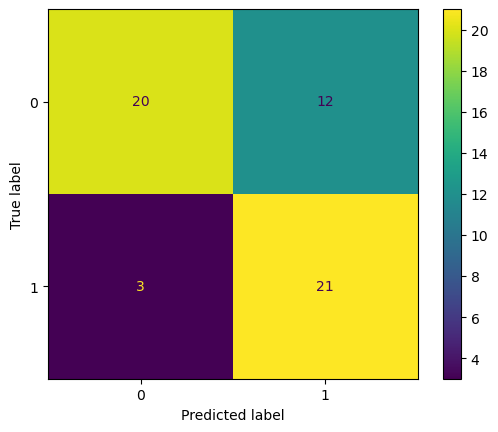

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_default)
plt.show()
